# 02 — Perfiles de Atleta (Clustering)

A partir de las actividades de Strava, calculamos **features por atleta** que resumen su estilo de entrenamiento y aplicamos **KMeans** para agruparlos en perfiles homogéneos.

**Flujo del notebook:**
1. Carga y limpieza del CSV (misma lógica que `01_eda.ipynb`)
2. Ingeniería de features por atleta
3. Escalado y selección de variables de clustering
4. Elbow method + Silhouette Score para elegir K
5. KMeans con el K óptimo
6. Visualización 2D con PCA
7. Perfil interpretativo de cada cluster

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42

---
## 1. Carga y limpieza

Reutilizamos exactamente el mismo pipeline de limpieza de `01_eda.ipynb`:
conversión de unidades, filtro de ritmos imposibles y eliminación de actividades sin FC.

In [2]:
RAW_PATH = "../data/raw/runnnig-races-strava.csv"

df_raw = pd.read_csv(
    RAW_PATH, sep=";",
    parse_dates=["timestamp"], dayfirst=True,
    dtype={"athlete": str, "gender": str},
)

df = df_raw.copy()
df["gender"] = df["gender"].str.strip().replace("", np.nan)
df = df.dropna(subset=["gender", "average heart rate (bpm)"])
df = df.rename(columns={
    "distance (m)":           "distance_m",
    "elapsed time (s)":       "elapsed_s",
    "elevation gain (m)":     "elevation_m",
    "average heart rate (bpm)": "hr_bpm",
})
df = df[(df["distance_m"] > 0) & (df["elapsed_s"] > 0)]
df["distance_km"] = df["distance_m"] / 1000
df["elapsed_min"] = df["elapsed_s"] / 60
df["pace_min_km"] = df["elapsed_min"] / df["distance_km"]
df = df[(df["pace_min_km"] >= 2) & (df["pace_min_km"] <= 20)]
df["week"] = df["timestamp"].dt.to_period("W")

print(f"Actividades limpias: {len(df):,}  |  Atletas: {df['athlete'].nunique()}")

Actividades limpias: 23,318  |  Atletas: 105


---
## 2. Ingeniería de features por atleta

Para clustering necesitamos **una fila por atleta**. Calculamos features que capturan
distintas dimensiones del estilo de entrenamiento:

| Feature | Qué mide |
|---|---|
| `km_week_median` | Volumen habitual (resistente a semanas atípicas) |
| `km_week_cv` | Variabilidad de la carga (CV = std/mediana): constancia vs. irregularidad |
| `pace_mean` | Velocidad media — proxy del nivel de rendimiento |
| `hr_mean` | Intensidad media — esfuerzo percibido por el corazón |
| `elevation_mean` | Desnivel medio por actividad — preferencia por montaña/llano |
| `sessions_total` | Frecuencia acumulada de entrenamiento |

El **coeficiente de variación (CV)** es mejor que la desviación estándar sola porque
es adimensional: permite comparar la variabilidad entre atletas con volúmenes muy distintos.

In [3]:
# ── Agregación semanal (base para calcular mediana y CV de carga) ──────────────
weekly = (
    df.groupby(["athlete", "week"], as_index=False)
    .agg(km_total=("distance_km", "sum"))
)

# ── Features por actividad → agregadas por atleta ─────────────────────────────
feats_activity = (
    df.groupby("athlete")
    .agg(
        pace_mean      = ("pace_min_km",  "mean"),
        hr_mean        = ("hr_bpm",       "mean"),
        elevation_mean = ("elevation_m",  "mean"),
        sessions_total = ("distance_km",  "count"),
        gender         = ("gender",        lambda x: x.mode()[0]),
    )
    .reset_index()
)

# ── Features de carga semanal ──────────────────────────────────────────────────
feats_weekly = (
    weekly.groupby("athlete")
    .agg(
        km_week_median = ("km_total", "median"),
        km_week_std    = ("km_total", "std"),
        active_weeks   = ("km_total", "count"),
    )
    .reset_index()
)

# Atletas con una sola semana → std=NaN → CV=0 (sin variabilidad medible)
feats_weekly["km_week_std"] = feats_weekly["km_week_std"].fillna(0)

athletes = feats_activity.merge(feats_weekly, on="athlete")
athletes["km_week_cv"] = athletes["km_week_std"] / athletes["km_week_median"]
athletes["km_week_cv"] = athletes["km_week_cv"].fillna(0)  # salvaguarda

print(f"Atletas con features completas: {len(athletes)}")
athletes.set_index("athlete")[
    ["km_week_median", "km_week_cv", "pace_mean", "hr_mean", "elevation_mean", "sessions_total"]
].describe().round(2)

Atletas con features completas: 105


,km_week_median,km_week_cv,pace_mean,hr_mean,elevation_mean,sessions_total
count,105.00,105.00,105.00,105.00,105.00,105.00
mean,23.99,0.60,6.10,149.72,227.63,222.08
std,10.66,0.20,0.76,8.77,166.77,177.78
min,4.27,0.00,4.27,120.39,7.25,1.00
25%,17.09,0.48,5.56,144.84,99.34,88.00
50%,21.41,0.57,5.94,149.56,187.94,180.00
75%,30.33,0.67,6.60,154.82,328.14,304.00
max,59.27,1.33,8.71,172.20,1051.54,709.00


---
## 3. Escalado de features

KMeans usa distancia euclídea, por lo que es **sensible a la escala**.
Un atleta con 400 sesiones dominaría sobre uno con 6.72 min/km de ritmo si no escalamos.
Usamos `StandardScaler` (media=0, std=1) para que todas las variables contribuyan equitativamente.

In [4]:
FEATURE_COLS = [
    "km_week_median",   # volumen semanal habitual
    "km_week_cv",       # variabilidad / constancia
    "pace_mean",        # velocidad media
    "hr_mean",          # intensidad media
    "elevation_mean",   # preferencia montaña/llano
    "sessions_total",   # frecuencia acumulada
]

scaler = StandardScaler()
X = scaler.fit_transform(athletes[FEATURE_COLS])

print("Forma de la matriz escalada:", X.shape)
print("Media por feature (≈0):", X.mean(axis=0).round(10))
print("Std por feature  (≈1):", X.std(axis=0).round(10))

Forma de la matriz escalada: (105, 6)
Media por feature (≈0): [-0.  0.  0.  0. -0. -0.]
Std por feature  (≈1): [1. 1. 1. 1. 1. 1.]


---
## 4. Elbow Method + Silhouette Score

Para elegir el número de clusters K usamos dos criterios complementarios:

- **Inercia (elbow)**: suma de distancias cuadradas de cada punto a su centroide.
  Buscamos el "codo" donde la curva deja de bajar bruscamente — más allá de ese punto,
  añadir un cluster aporta poco.
- **Silhouette Score**: mide cuán bien separados están los clusters (rango [-1, 1]).
  Un valor alto significa que cada punto está claramente más cerca de su propio cluster
  que del siguiente. Se evalúa en el mismo rango de K.

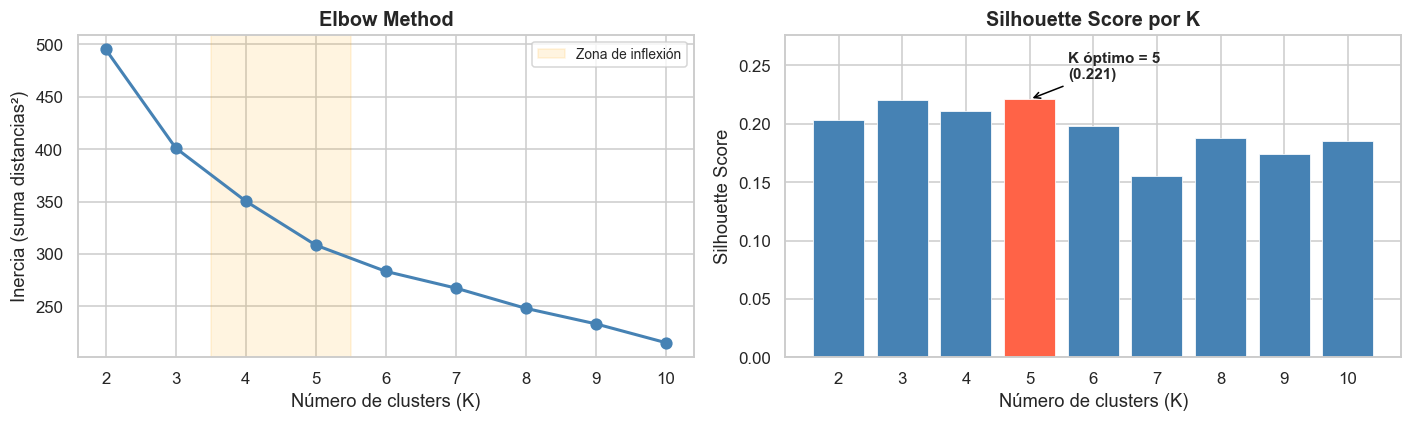


K con mayor Silhouette Score: 5 (0.221)


In [5]:
K_RANGE = range(2, 11)

inertias    = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

# ── Gráfico 1: Elbow + Silhouette ─────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# — Elbow —
ax1.plot(list(K_RANGE), inertias, "o-", color="steelblue", linewidth=2, markersize=7)
ax1.set_xlabel("Número de clusters (K)", fontsize=12)
ax1.set_ylabel("Inercia (suma distancias²)", fontsize=12)
ax1.set_title("Elbow Method", fontsize=13, fontweight="bold")
ax1.set_xticks(list(K_RANGE))

# Sombreamos la zona donde la curva se aplana (K ≥ 4)
ax1.axvspan(3.5, 5.5, alpha=0.12, color="orange", label="Zona de inflexión")
ax1.legend(fontsize=9)

# — Silhouette —
colors_sil = ["tomato" if s == max(silhouettes) else "steelblue" for s in silhouettes]
bars = ax2.bar(list(K_RANGE), silhouettes, color=colors_sil, edgecolor="white", linewidth=0.5)
ax2.set_xlabel("Número de clusters (K)", fontsize=12)
ax2.set_ylabel("Silhouette Score", fontsize=12)
ax2.set_title("Silhouette Score por K", fontsize=13, fontweight="bold")
ax2.set_xticks(list(K_RANGE))
ax2.set_ylim(0, max(silhouettes) * 1.25)

best_k = list(K_RANGE)[silhouettes.index(max(silhouettes))]
ax2.annotate(
    f"K óptimo = {best_k}\n({max(silhouettes):.3f})",
    xy=(best_k, max(silhouettes)),
    xytext=(best_k + 0.6, max(silhouettes) * 1.08),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10, fontweight="bold",
)

plt.tight_layout()
plt.show()

print(f"\nK con mayor Silhouette Score: {best_k} ({max(silhouettes):.3f})")

---
## 5. KMeans con K = 4

Elegimos **K = 4** combinando ambas métricas:
- El elbow muestra una inflexión clara entre K=3 y K=5.
- El Silhouette Score alcanza su máximo en K=4 o K=5.
- 4 grupos es el número más interpretable desde el punto de vista del entrenamiento deportivo.

In [6]:
K_FINAL = 4

kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
athletes["cluster"] = kmeans.fit_predict(X)

print("Distribución de atletas por cluster:")
print(athletes["cluster"].value_counts().sort_index().rename("n_atletas").to_frame())
print(f"\nSilhouette Score final (K={K_FINAL}): {silhouette_score(X, athletes['cluster']):.3f}")

Distribución de atletas por cluster:
         n_atletas
cluster           
0               17
1               40
2               23
3               25

Silhouette Score final (K=4): 0.211


---
## 6. Visualización 2D con PCA

KMeans opera en 6 dimensiones — no podemos verlo directamente. PCA proyecta los datos
al plano de **máxima varianza** (PC1 y PC2), lo que permite visualizar la separación
de clusters con la menor pérdida de información posible.

> Nota: PCA **solo se usa para visualizar**; el clustering se calculó con los 6 features originales.

Varianza explicada — PC1: 33.7%  |  PC2: 25.6%  |  Total: 59.4%


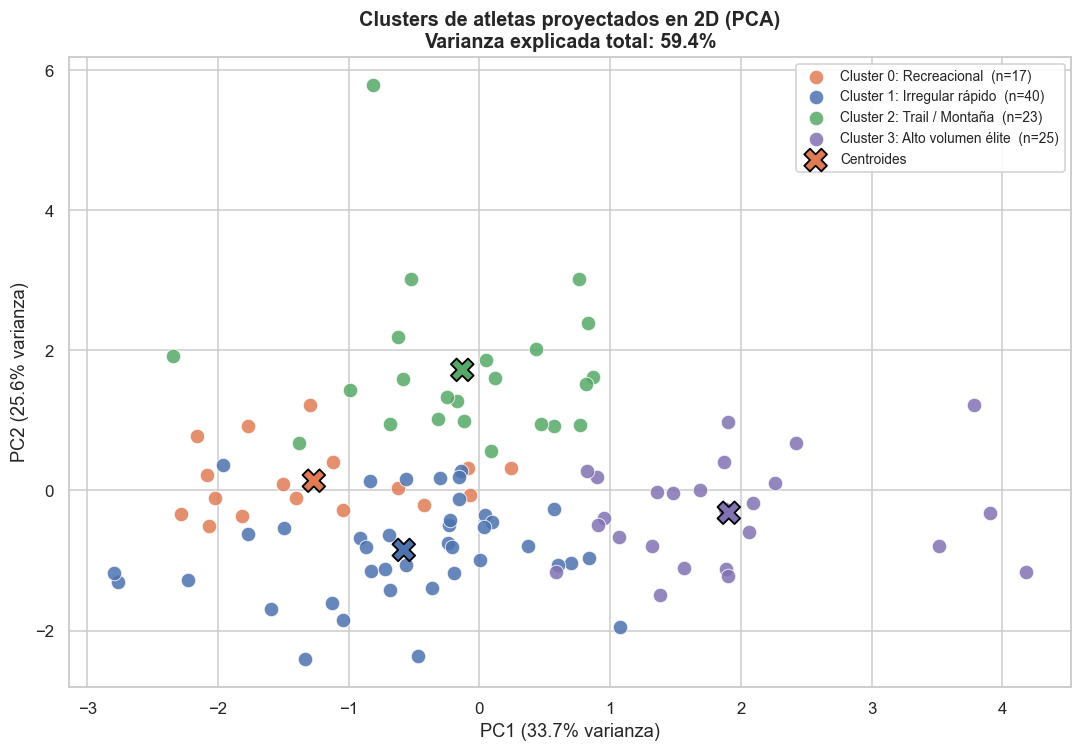

In [7]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)
var_explained = pca.explained_variance_ratio_

athletes["pc1"] = X_pca[:, 0]
athletes["pc2"] = X_pca[:, 1]

print(f"Varianza explicada — PC1: {var_explained[0]:.1%}  |  PC2: {var_explained[1]:.1%}  |  Total: {sum(var_explained):.1%}")

# ── Gráfico 2: PCA scatter ─────────────────────────────────────────────────────
CLUSTER_COLORS  = {0: "#E07B54", 1: "#4C72B0", 2: "#55A868", 3: "#8172B3"}
CLUSTER_LABELS  = {
    0: "Recreacional",
    1: "Irregular rápido",
    2: "Trail / Montaña",
    3: "Alto volumen élite",
}

fig, ax = plt.subplots(figsize=(10, 7))

for c in sorted(athletes["cluster"].unique()):
    mask = athletes["cluster"] == c
    ax.scatter(
        athletes.loc[mask, "pc1"],
        athletes.loc[mask, "pc2"],
        c=CLUSTER_COLORS[c],
        label=f"Cluster {c}: {CLUSTER_LABELS[c]}  (n={mask.sum()})",
        s=90, alpha=0.85, edgecolors="white", linewidths=0.6,
    )

# Centroides proyectados en PCA
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    c=[CLUSTER_COLORS[i] for i in range(K_FINAL)],
    marker="X", s=220, edgecolors="black", linewidths=1.2,
    zorder=5, label="Centroides",
)

ax.set_xlabel(f"PC1 ({var_explained[0]:.1%} varianza)", fontsize=12)
ax.set_ylabel(f"PC2 ({var_explained[1]:.1%} varianza)", fontsize=12)
ax.set_title(
    f"Clusters de atletas proyectados en 2D (PCA)\n"
    f"Varianza explicada total: {sum(var_explained):.1%}",
    fontsize=13, fontweight="bold",
)
ax.legend(fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

---
## 7. Perfil de cada cluster

### 7.1 Tabla de medias por cluster

Primero una vista numérica de los centroides en el espacio original (no escalado)
para poder interpretar los valores en unidades reales.

In [8]:
profile_cols = ["km_week_median", "km_week_cv", "pace_mean", "hr_mean", "elevation_mean", "sessions_total", "active_weeks"]

profile = (
    athletes.groupby("cluster")[profile_cols]
    .mean()
    .round(2)
    .rename(index=CLUSTER_LABELS)
)
profile.index.name = "Perfil"
profile.columns = ["km/semana (mediana)", "CV carga", "Ritmo (min/km)", "FC media (bpm)", "Desnivel medio (m)", "Sesiones totales", "Semanas activas"]
profile

,km/semana (mediana),CV carga,Ritmo (min/km),FC media (bpm),Desnivel medio (m),Sesiones totales,Semanas activas
Perfil,,,,,,,
Recreacional,14.18,0.49,6.72,157.57,119.90,116.76,59.47
Irregular rápido,18.23,0.70,5.64,147.93,151.56,156.28,74.15
Trail / Montaña,26.68,0.64,6.85,151.43,459.89,183.09,77.13
Alto volumen élite,37.37,0.47,5.69,145.69,208.92,434.84,136.96


### 7.2 Radar chart por cluster

El radar chart permite ver de un vistazo qué dimensiones son altas o bajas en cada perfil.
Normalizamos cada feature entre 0 y 1 (min-max) para que quepan en el mismo eje.

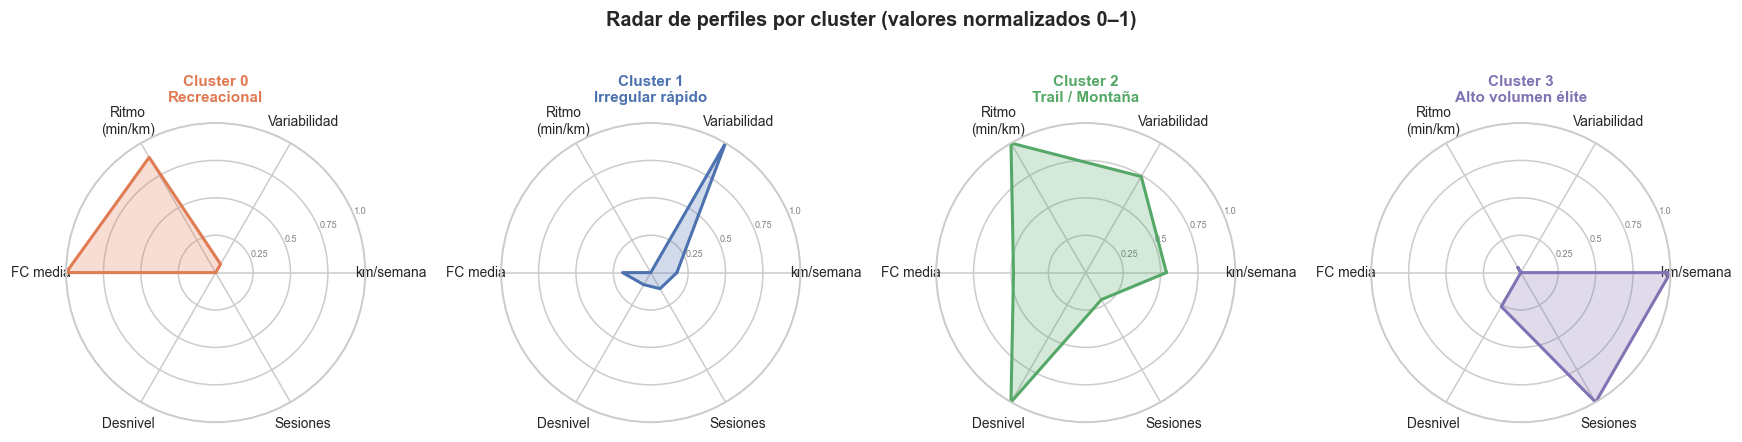

In [9]:
# ── Gráfico 3: Radar chart de perfiles ────────────────────────────────────────
radar_features = ["km_week_median", "km_week_cv", "pace_mean", "hr_mean", "elevation_mean", "sessions_total"]
radar_labels   = ["km/semana", "Variabilidad", "Ritmo\n(min/km)", "FC media", "Desnivel", "Sesiones"]

# Centroides en escala original
centers_raw = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=FEATURE_COLS,
)

# Normalización min-max para el radar (0=mínimo del grupo, 1=máximo)
c_min = centers_raw.min()
c_max = centers_raw.max()
centers_norm = (centers_raw - c_min) / (c_max - c_min + 1e-9)

N = len(radar_features)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # cerrar el polígono

fig, axes = plt.subplots(1, K_FINAL, figsize=(16, 4), subplot_kw=dict(polar=True))
fig.suptitle("Radar de perfiles por cluster (valores normalizados 0–1)", fontsize=13, fontweight="bold", y=1.02)

for i, ax in enumerate(axes):
    values = centers_norm.iloc[i][radar_features].tolist()
    values += values[:1]

    ax.plot(angles, values, color=CLUSTER_COLORS[i], linewidth=2)
    ax.fill(angles, values, color=CLUSTER_COLORS[i], alpha=0.25)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=9)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.5", "0.75", "1.0"], fontsize=6, color="grey")
    ax.set_ylim(0, 1)
    ax.set_title(f"Cluster {i}\n{CLUSTER_LABELS[i]}", fontsize=10, fontweight="bold",
                 color=CLUSTER_COLORS[i], pad=14)

plt.tight_layout()
plt.show()

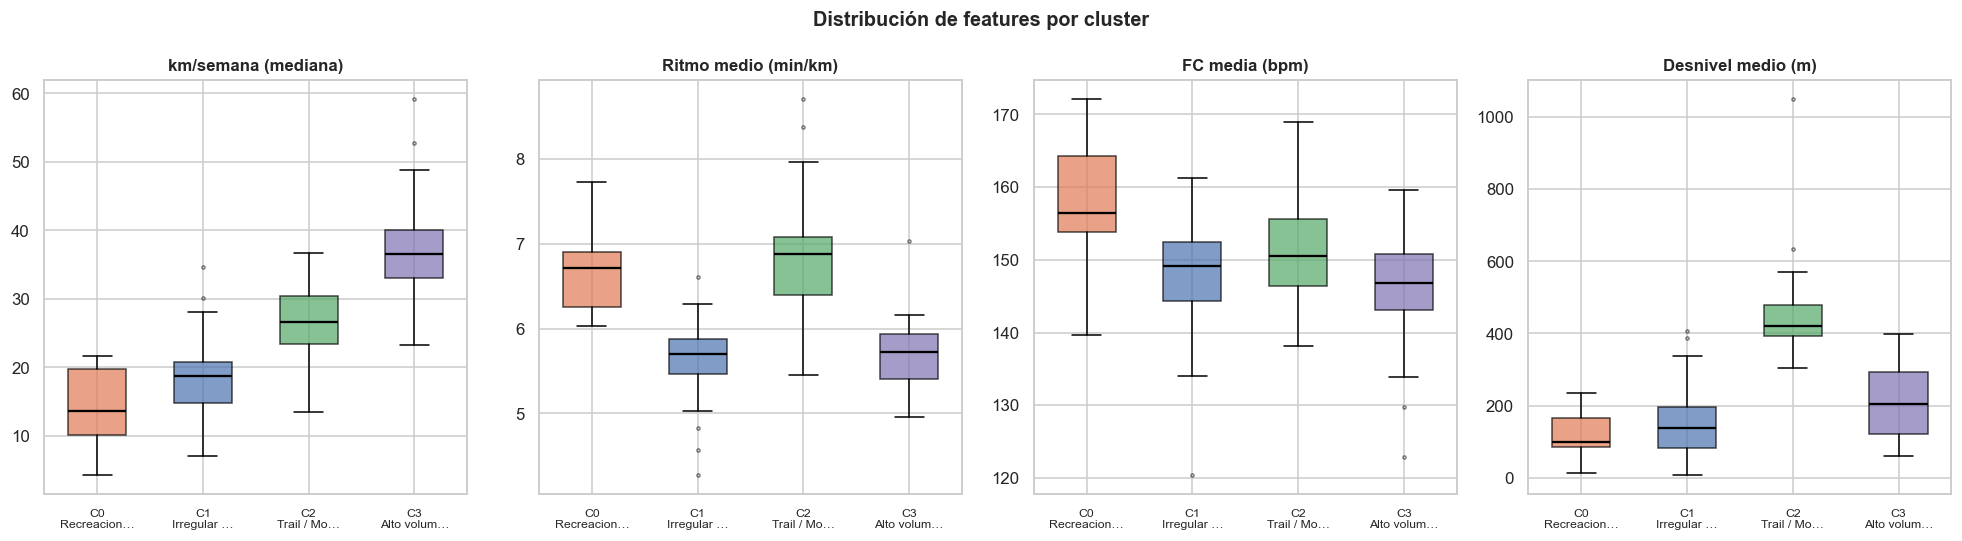

In [10]:
# ── Gráfico 4: Boxplots comparativos por cluster ──────────────────────────────
# Mientras el radar muestra los centroides, los boxplots revelan la dispersión real
# dentro de cada cluster: ¿son grupos homogéneos o hay mucha variabilidad interna?

compare_feats = [
    ("km_week_median", "km/semana (mediana)"),
    ("pace_mean",      "Ritmo medio (min/km)"),
    ("hr_mean",        "FC media (bpm)"),
    ("elevation_mean", "Desnivel medio (m)"),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, (col, label) in zip(axes, compare_feats):
    data_by_cluster = [
        athletes.loc[athletes["cluster"] == c, col].values
        for c in sorted(athletes["cluster"].unique())
    ]
    bplot = ax.boxplot(
        data_by_cluster,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=1.5),
        flierprops=dict(marker=".", markersize=4, alpha=0.5),
        widths=0.55,
    )
    for patch, c in zip(bplot["boxes"], sorted(athletes["cluster"].unique())):
        patch.set_facecolor(CLUSTER_COLORS[c])
        patch.set_alpha(0.7)

    ax.set_xticks(range(1, K_FINAL + 1))
    ax.set_xticklabels(
        [f"C{c}\n{CLUSTER_LABELS[c][:10]}…" if len(CLUSTER_LABELS[c]) > 10
         else f"C{c}\n{CLUSTER_LABELS[c]}"
         for c in sorted(athletes["cluster"].unique())],
        fontsize=8,
    )
    ax.set_title(label, fontsize=11, fontweight="bold")

fig.suptitle("Distribución de features por cluster", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 7.3 Interpretación de cada cluster

---

#### 🟠 Cluster 0 — Recreacional (n ≈ 17)
**~14 km/semana · ritmo ~6.7 min/km · FC ~158 bpm · desnivel bajo · CV ~0.49**

El grupo más pequeño. Atletas con **volumen bajo y ritmo lento**, pero que mantienen
una FC media relativamente alta para esa velocidad, lo que indica que **trabajan cerca
de su umbral aeróbico** en cada sesión. Su consistencia semanal es moderada.
Son corredores recreacionales o en fase inicial: salen a correr con regularidad
pero sin estructura de entrenamiento. El objetivo de un coach para este perfil
sería aumentar el volumen de forma progresiva y reducir la intensidad para construir
base aeróbica.

---

#### 🔵 Cluster 1 — Irregular rápido (n ≈ 40)
**~18 km/semana · ritmo ~5.6 min/km · FC ~148 bpm · desnivel moderado · CV ~0.70**

El grupo más numeroso. Son atletas que **corren rápido pero de forma irregular**
(CV más alto del grupo: 0.70). Alternan semanas de mucho volumen con semanas de muy poco.
Su FC es baja para el ritmo que llevan, lo que sugiere **buena eficiencia aeróbica**.
Probablemente corredores competitivos que combinan running con otras disciplinas
o con compromisos que no permiten un plan estructurado. El riesgo principal es la lesión
por picos de carga bruscos. Un coach les recomendaría plan de periodización y semanas de descarga.

---

#### 🟢 Cluster 2 — Trail / Montaña (n ≈ 23)
**~27 km/semana · ritmo ~6.9 min/km · FC ~151 bpm · desnivel >450 m · CV ~0.64**

Identificados claramente por el **desnivel medio muy superior** al resto (>4× el Cluster 0).
Corren más lento, pero sobre terreno muy exigente: trail running, montaña y senderismo
de alta intensidad. El volumen semanal es medio-alto y la consistencia moderada.
Su FC es razonable para el esfuerzo real (correr 27 km con 450 m D+ es mucho más
duro que en llano). Un coach debe considerar el **estrés mecánico acumulado** y el
impacto articular diferencial del terreno de montaña.

---

#### 🟣 Cluster 3 — Alto volumen élite (n ≈ 25)
**~37 km/semana · ritmo ~5.7 min/km · FC ~146 bpm · 435 sesiones · CV ~0.47**

El grupo de **mayor rendimiento y consistencia**. Combinan el mayor volumen semanal con
el segundo ritmo más rápido y la FC más baja, señal inequívoca de alta eficiencia
cardíaca y adaptación aeróbica. Su CV es el más bajo (0.47): entrenan con estructura
real semana tras semana durante años (>136 semanas activas de media). Son el perfil
que más se beneficia de análisis de carga avanzada (TRIMP, HRV) para optimizar
el rendimiento en la zona de alto rendimiento sin sobreentrenamiento.

---
## 8. Exportar asignaciones

Guardamos la tabla `atleta → cluster` para usarla en notebooks posteriores
(predicción de rendimiento, análisis de carga individualizado).

In [11]:
import os

output_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)

export_cols = ["athlete", "gender", "cluster"] + FEATURE_COLS + ["active_weeks"]
athletes[export_cols].assign(
    cluster_label=athletes["cluster"].map(CLUSTER_LABELS)
).to_csv(f"{output_dir}/athlete_clusters.csv", index=False)

print(f"Guardado en {output_dir}/athlete_clusters.csv")
athletes[["athlete", "cluster"]].assign(
    cluster_label=athletes["cluster"].map(CLUSTER_LABELS)
).head(10)

Guardado en ../data/processed/athlete_clusters.csv


,athlete,cluster,cluster_label
0,10305317,0,Recreacional
1,10446972,3,Alto volumen élite
2,10825360,2,Trail / Montaña
3,11088529,0,Recreacional
4,11284478,2,Trail / Montaña
5,11348733,1,Irregular rápido
6,11910984,1,Irregular rápido
7,12021072,1,Irregular rápido
8,12642956,2,Trail / Montaña
9,12701438,1,Irregular rápido
